In [28]:
# Water Quality Exploratory Data Analysis

<a id ='1'></a>
## Pyton Libraries   

<a id ='2'></a>
## Read and Analyse Data

In [30]:
water_data = pd.read_csv('C:/Users/iraga/OneDrive/Documents/water_qualirty/water_qualirty/water_potability1.csv')

In [31]:
water_data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,10.379783,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,15.180013,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,16.868637,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,18.436525,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,11.558279,0


In [32]:
water_data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,14.284970,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,3.308162,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,2.200000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,12.065801,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,14.218338,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,16.557652,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,28.300000,1.000000


In [33]:
water_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ph              2785 non-null   float64
 1   Hardness        3276 non-null   float64
 2   Solids          3276 non-null   float64
 3   Chloramines     3276 non-null   float64
 4   Sulfate         2495 non-null   float64
 5   Organic_carbon  3276 non-null   float64
 6   Potability      3276 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 179.3 KB


<a id ='3'></a>
## Dependent Variable Analysis

c:\users\dell\appdata\local\programs\python\python37\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


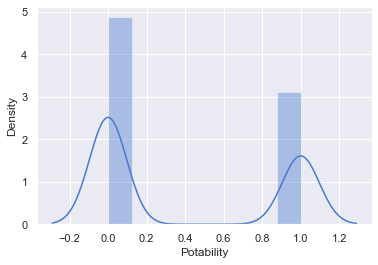

In [34]:
import seaborn as sns
sns.set(color_codes=True)
sns.set_palette(sns.color_palette("muted"))

sns.distplot(water_data["Potability"].dropna());

<a id ='4'></a>
## Correlation Between Features

In [35]:
water_data.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.043503,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,0.003610,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.010242,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.012653,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,0.030831,-0.023577
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,1.000000,-0.030001
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.030001,1.000000


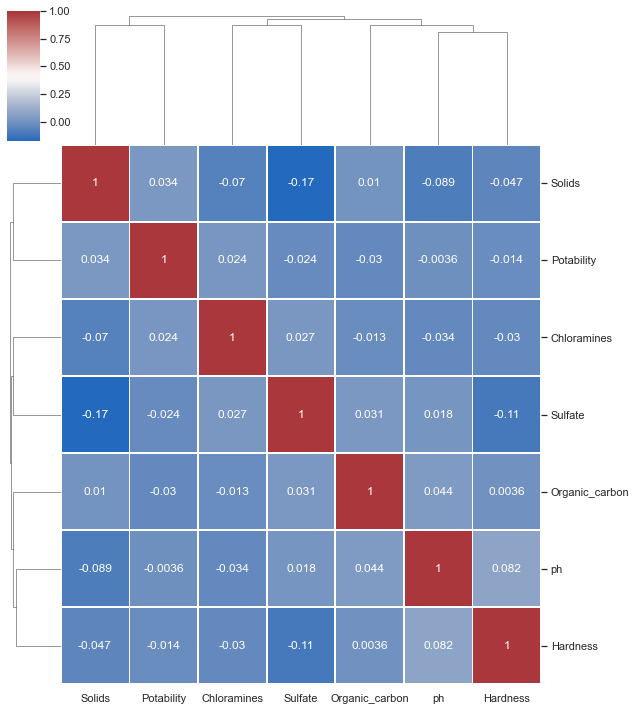

In [36]:
sns.clustermap(water_data.corr(), cmap = 'vlag', dendrogram_ratio =(0.1, 0.2), annot= True, linewidths =.8, figsize = (9,10) )
plt.show()

<a id ='5'></a>
## Distribution of Features

c:\users\dell\appdata\local\programs\python\python37\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
c:\users\dell\appdata\local\programs\python\python37\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
No handles with labels found to put in legend.


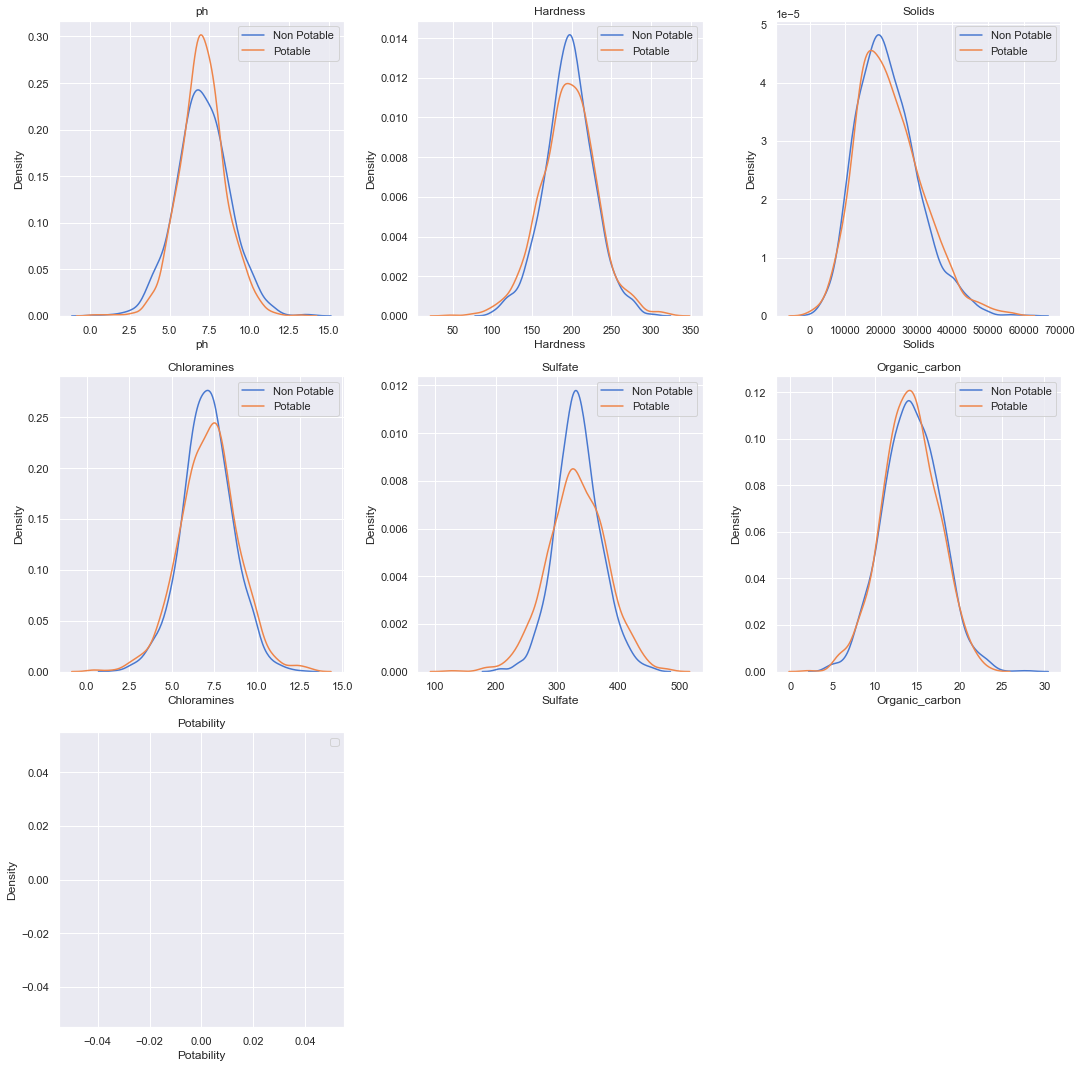

In [37]:
non_potable = water_data.query('Potability == 0')
potable = water_data.query('Potability == 1')
plt.figure(figsize = (15,15))
for ax, col in enumerate(water_data.columns[:9]):
    plt.subplot(3, 3, ax+1)
    plt.title(col)
    sns.kdeplot(x = non_potable[col], label = "Non Potable")
    sns.kdeplot(x = potable[col], label = "Potable")
    plt.legend()
plt.tight_layout()

<a id ='6'></a>
## Preprocessing: Missing Value Problem

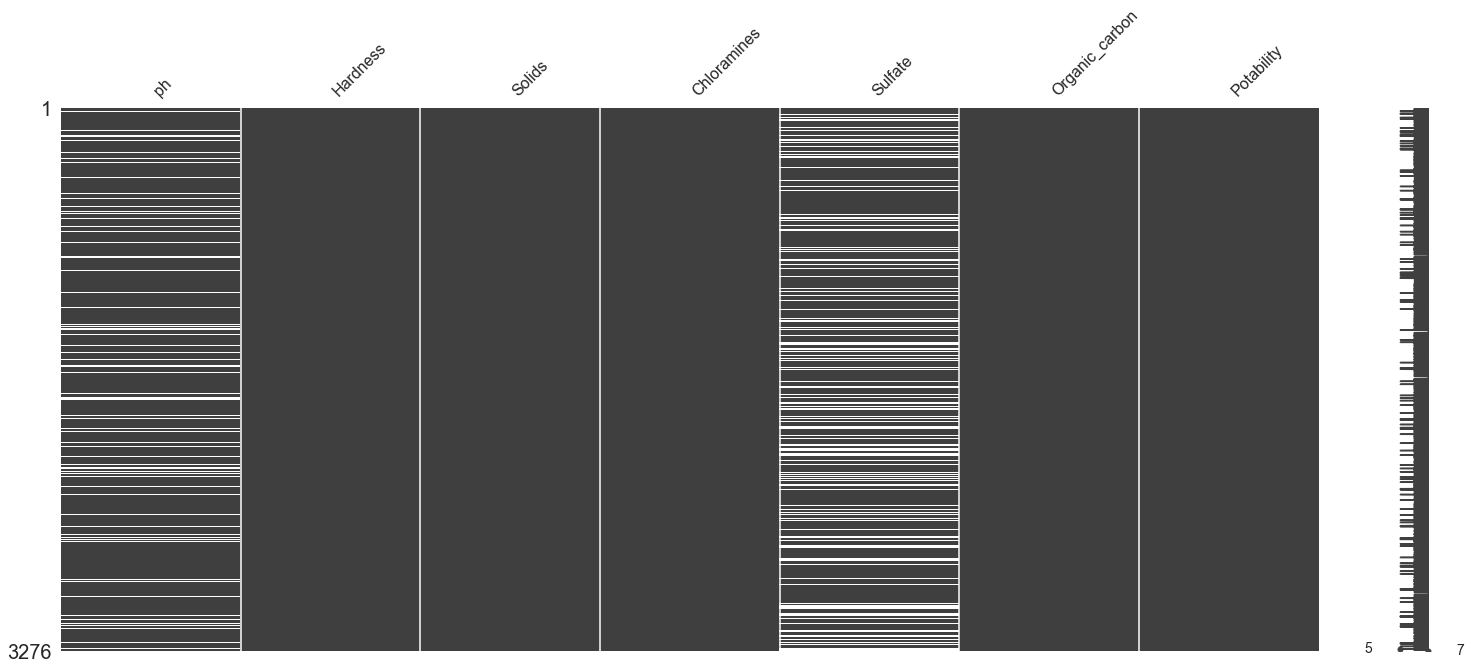

In [38]:
msno.matrix(water_data)
plt.show()

In [39]:
water_data.isnull().sum()

ph                491
Hardness            0
Solids              0
Chloramines         0
Sulfate           781
Organic_carbon      0
Potability          0
dtype: int64

In [40]:
water_data['ph'].fillna(value = water_data['ph'].mean(), inplace = True)
water_data['Sulfate'].fillna(value = water_data['Sulfate'].mean(), inplace = True)
water_data['Chloramines'].fillna(value = water_data['Chloramines'].mean(), inplace = True)

In [41]:
water_data.isnull().sum()

ph                0
Hardness          0
Solids            0
Chloramines       0
Sulfate           0
Organic_carbon    0
Potability        0
dtype: int64

<a id ='7'></a>
## Preprocessing: Train-Test Split and Normalization

In [42]:
x = water_data.drop('Potability', axis =1).values 
y = water_data['Potability'].values

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=3)
print('x_train', x_train.shape)
print('x_test', x_test.shape)
print('y_train', y_train.shape)
print('y_test', y_test.shape)

x_train (2293, 6)
x_test (983, 6)
y_train (2293,)
y_test (983,)


In [44]:
#min-max normalization
x_train_max = np.max(x_train)
x_train_min = np.min(x_train)
x_train = (x_train - x_train_min)/(x_train_max - x_train_min)

#hem test hem de train veri setini traine göre normalize ettiğimiz için x'in min max'ını bulmamıza gerek yok
x_test = (x_test - x_train_min)/(x_train_max - x_train_min)

In [73]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,RobustScaler
from sklearn.linear_model import LinearRegression,Lasso,ElasticNet
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
import xgboost as xgb
from prettytable import PrettyTable
from sklearn.metrics import mean_squared_log_error, mean_absolute_error

In [74]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [75]:
Y_predict=model.predict(x_test)
Y_train_predict=model.predict(x_train)

In [76]:
score_lr=r2_score(y_train,Y_train_predict)
print(f"R2 train Score Of Linear Regression : {score_lr}")

R2 train Score Of Linear Regression : 0.0029680645555352214


In [77]:
print("Mean Squared Error: ", mean_squared_error(y_train,Y_train_predict))
print("Mean Absolute Error: ", mean_absolute_error(y_train,Y_train_predict))

Mean Squared Error:  0.23678197430763792
Mean Absolute Error:  0.47356394861527606


<a id ='8'></a>
## Modelling: Decision Tree and Random Forest Classifiers

In [45]:
models = [('DTC', DecisionTreeClassifier(max_depth=3)),
          ('RF', RandomForestClassifier())]

In [46]:
finalResults = []
cmList = []
for name, model in models:
    model.fit(x_train, y_train)
    model_result = model.predict(x_test)
    score = precision_score(y_test, model_result)
    cm = confusion_matrix(y_test, model_result)
    
    finalResults.append((name, score))
    cmList.append((name, cm))
finalResults    

[('DTC', 0.5687203791469194), ('RF', 0.6635071090047393)]

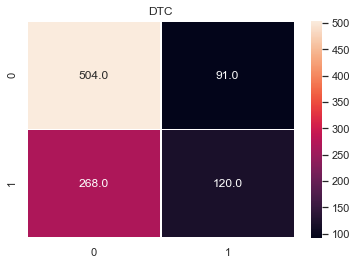

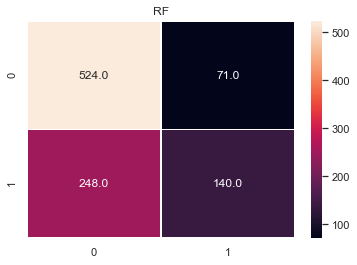

In [47]:
for name, i in cmList:
    plt.figure()
    sns.heatmap(i, annot = True, linewidth = 0.8, fmt = '.1f')
    plt.title(name)
    plt.show()

<a id ='9'></a>
## Visualize Decision Tree

In [48]:
dt_clf = models[0][1]
dt_clf 

DecisionTreeClassifier(max_depth=3)

In [49]:
water_data.columns.tolist()[:-1]

['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Organic_carbon']

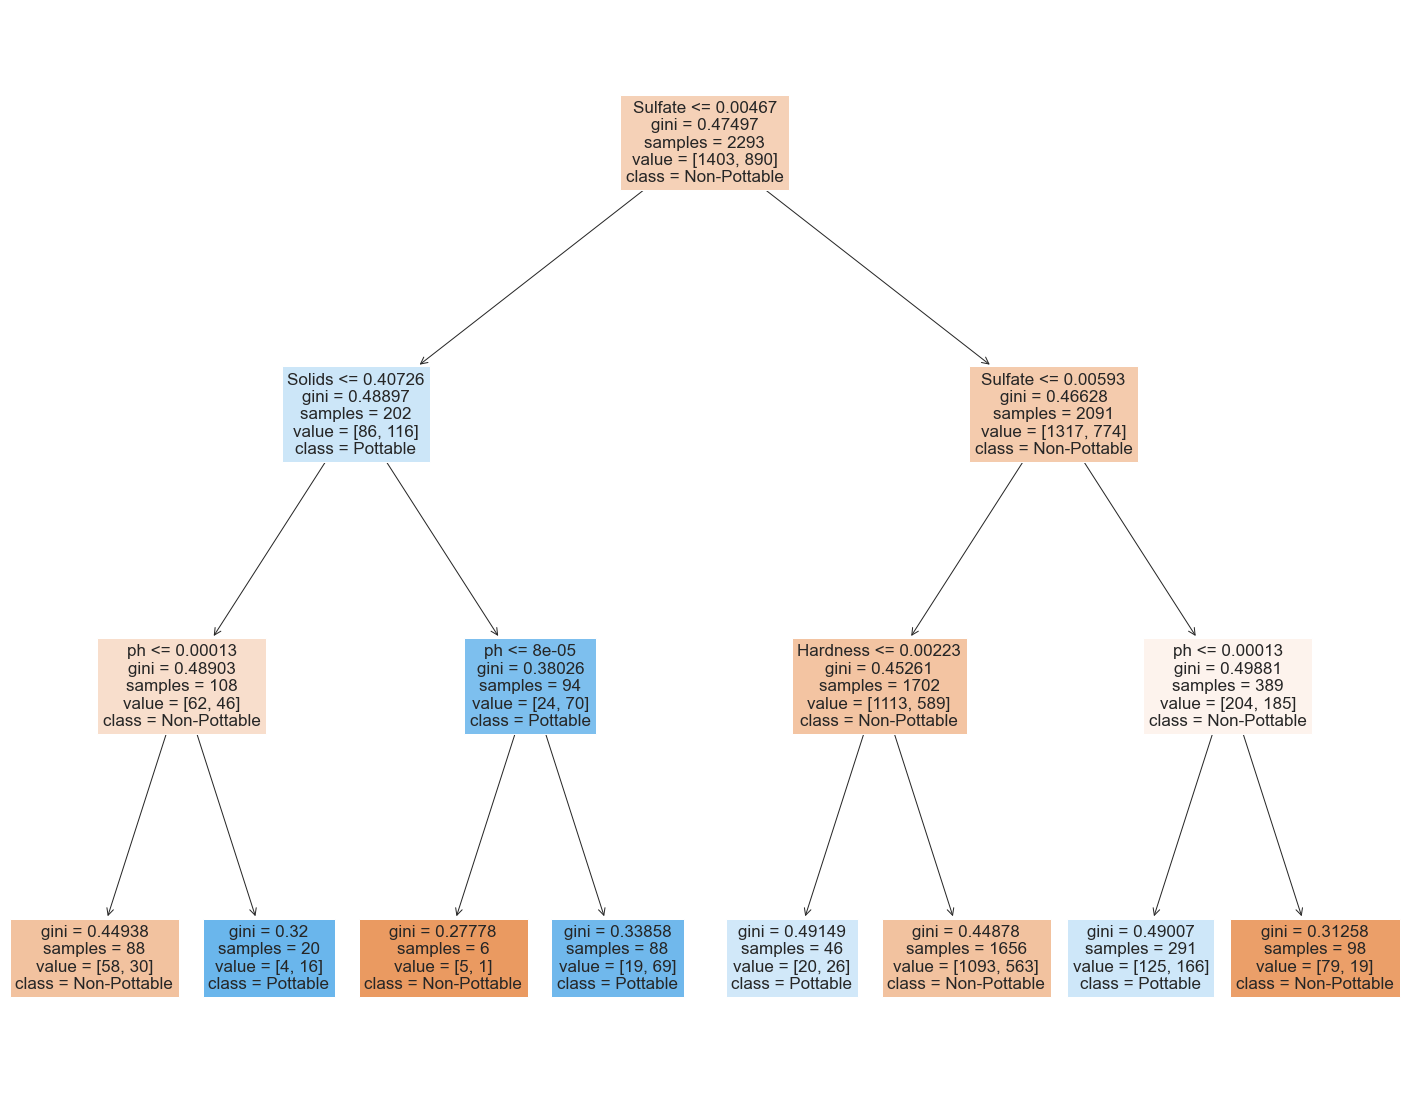

In [50]:
plt.figure(figsize = (25,20))
tree.plot_tree(dt_clf,
               feature_names = water_data.columns.tolist()[:-1],
               class_names = ['Non-Pottable','Pottable'],
               filled = True,
               precision = 5)
plt.show()

<a id ='10'></a>
## Random Forest Hyperparameter Tuning

In [51]:
model_params = {
    'Random Forest':
    {
        'model': RandomForestClassifier(),
        'params':
        {
            'n_estimators':[10, 50, 100],
            'max_features':['auto','sqrt','log2'],
            'max_depth':list(range(1,15,3))
        }
    }
}
model_params

{'Random Forest': {'model': RandomForestClassifier(),
  'params': {'n_estimators': [10, 50, 100],
   'max_features': ['auto', 'sqrt', 'log2'],
   'max_depth': [1, 4, 7, 10, 13]}}}

In [52]:
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2)
scores = []
for model_name, params in model_params.items():
    rs = RandomizedSearchCV(params["model"], params["params"], cv = cv, n_iter = 10)
    rs.fit(x,y)
    scores.append([model_name, dict(rs.best_params_),rs.best_score_])
scores

[['Random Forest',
  {'n_estimators': 50, 'max_features': 'sqrt', 'max_depth': 13},
  0.6759749115620928]]